# Project 2 Pipeline - Agricultural Intensity vs. Air Quality 


**Pipeline stages:**
1. Data Acquisition: download EPA AQI and USDA Census of Agriculture data
2. Data Preparation: clean, merge, and engineer features
3. MongoDB Storage: push merged data into Atlas collection
4. Analysis: query MongoDB, build regression model
5. Visualization: publication-quality charts

In [1]:
# IMPORTS
import requests
import zipfile
import io
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import pymongo
from pymongo import MongoClient

# Logging setup 
logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s  %(levelname)s  %(message)s'
)
logger = logging.getLogger(__name__)
logger.info('Pipeline started')

/Users/yuthimadireddy/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/yuthimadireddy/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Importing environment variables
from dotenv import load_dotenv
import os

load_dotenv()

MONGO_URI = os.getenv('MONGO_URI')


In [3]:
#  1a. EPA Annual AQI by County 2022
# Source: https://aqs.epa.gov/aqsweb/airdata/download_files.html

def download_epa_aqi(year: int = 2022) -> pd.DataFrame:
    """Download and parse the EPA annual AQI by county CSV for a given year."""
    url = f"https://aqs.epa.gov/aqsweb/airdata/annual_aqi_by_county_{year}.zip"
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(response.content))
        df = pd.read_csv(z.open(z.namelist()[0]))
        logger.info(f'EPA AQI {year}: {len(df)} rows downloaded')
        return df
    except Exception as e:
        logger.error(f'EPA download failed: {e}')
        raise

# Test the EPA AQI download function
aqi_raw = download_epa_aqi(2022)
print(f'EPA AQI rows: {len(aqi_raw)}')
print(aqi_raw.head(3).to_string())

EPA AQI rows: 1003
     State   County  Year  Days with AQI  Good Days  Moderate Days  Unhealthy for Sensitive Groups Days  Unhealthy Days  Very Unhealthy Days  Hazardous Days  Max AQI  90th Percentile AQI  Median AQI  Days CO  Days NO2  Days Ozone  Days PM2.5  Days PM10
0  Alabama  Baldwin  2022            281        237             44                                    0               0                    0               0       97                   52          39        0         0         201          80          0
1  Alabama     Clay  2022            115         91             24                                    0               0                    0               0       68                   56          34        0         0           0         115          0
2  Alabama   DeKalb  2022            364        323             41                                    0               0                    0               0       97                   52          38        0         0     

In [4]:
# ── 1b. USDA Census of Agriculture 2017 - Cattle Inventory ───────────────────
# Downloaded directly from NASS Quick Stats (Census 2017, County level, TOTAL domain)
# Source: https://quickstats.nass.usda.gov

cattle_raw = pd.read_csv('../data/usda_nass_data.csv')

# Keep only TOTAL domain rows to avoid sub-category duplicates
cattle_raw = cattle_raw[cattle_raw['Domain'] == 'TOTAL'].copy()

# Drop suppressed values (D)/(Z) and rows with missing county FIPS
cattle_raw = cattle_raw[~cattle_raw['Value'].str.strip().isin(['(D)', '(Z)', ''])].copy()
cattle_raw = cattle_raw.dropna(subset=['County ANSI'])

# Build 5-digit FIPS and convert Value to numeric
cattle_raw['state_fips']  = cattle_raw['State ANSI'].astype(str).str.zfill(2)
cattle_raw['county_fips'] = cattle_raw['County ANSI'].astype(int).astype(str).str.zfill(3)
cattle_raw['fips']        = cattle_raw['state_fips'] + cattle_raw['county_fips']
cattle_raw['Value']       = cattle_raw['Value'].str.replace(',', '', regex=False).astype(float)

cattle_df = cattle_raw.groupby('fips', as_index=False)['Value'].sum()
cattle_df = cattle_df.rename(columns={'Value': 'cattle_inventory'})

logger.info(f'Cattle inventory rows: {len(cattle_df)}')
print(f'Cattle rows: {len(cattle_df)}')
print(cattle_df.head(3).to_string())


Cattle rows: 3024
    fips  cattle_inventory
0  01001           16466.0
1  01003           22381.0
2  01005           22548.0


In [5]:
# ── 2a. USDA data is already FIPS-keyed from cell 1b ────────────────────────
# cattle_df already has a 'fips' column built in the previous cell.
# We use cattle_inventory as the single agricultural proxy.
# Rename for the merge step so downstream code is consistent.

usda = cattle_df.copy()
print(f'USDA shape: {usda.shape}')
print(usda.head(3).to_string())

USDA shape: (3024, 2)
    fips  cattle_inventory
0  01001           16466.0
1  01003           22381.0
2  01005           22548.0


In [7]:
# ── 2b. Build FIPS for EPA AQI dataset ────────────────────────────────────────

crosswalk_url = (
    "https://www2.census.gov/geo/docs/reference/codes2020/"
    "national_county2020.txt"
)
try:
    xwalk = pd.read_csv(
        crosswalk_url,
        sep='|',
        dtype=str
    )
    # Print columns so we can see exact names
    print('Crosswalk columns:', xwalk.columns.tolist())
    
    xwalk['fips'] = xwalk['STATEFP'].str.zfill(2) + xwalk['COUNTYFP'].str.zfill(3)
    xwalk['county_clean'] = (
        xwalk['COUNTYNAME']
        .str.replace(r'\s+(County|Parish|Borough|Census Area|Municipality|city)$',
                     '', regex=True)
        .str.strip()
        .str.lower()
    )
    # Use STATE column (2-letter abbreviation) — actual column name from file
    state_col = [c for c in xwalk.columns if 'STATE' in c.upper() and c != 'STATEFP'][0]
    print('State abbreviation column:', state_col)
    xwalk = xwalk.rename(columns={state_col: 'state_ab'})
    
    logger.info(f'FIPS crosswalk loaded: {len(xwalk)} rows')
except Exception as e:
    logger.error(f'FIPS crosswalk download failed: {e}')
    raise

# Prepare AQI side
aqi = aqi_raw.copy()
aqi['county_clean'] = aqi['County'].str.lower().str.strip()
aqi['state_clean']  = aqi['State'].str.strip()

STATE_ABBREV = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC'
}

aqi['state_ab'] = aqi['state_clean'].map(STATE_ABBREV)

xwalk_sub = xwalk[['fips', 'county_clean', 'state_ab']]
aqi_with_fips = aqi.merge(xwalk_sub, on=['state_ab', 'county_clean'], how='left')

matched = aqi_with_fips['fips'].notna().sum()
print(f'AQI rows matched to FIPS: {matched}/{len(aqi_with_fips)} ({matched/len(aqi_with_fips)*100:.1f}%)')

Crosswalk columns: ['STATE', 'STATEFP', 'COUNTYFP', 'COUNTYNS', 'COUNTYNAME', 'CLASSFP', 'FUNCSTAT']
State abbreviation column: STATE
AQI rows matched to FIPS: 974/1006 (96.8%)


In [8]:
# ── 2c. Final merge: EPA AQI + USDA Agricultural Metrics ─────────────────────
# Keep only counties with >= 50 AQI measurement days (EPA recommended threshold)

aqi_clean = aqi_with_fips[
    (aqi_with_fips['Days with AQI'] >= 50) &
    (aqi_with_fips['fips'].notna())
].copy()

# Merge AQI with USDA cattle data on fips
merged = aqi_clean.merge(usda, on='fips', how='inner')
print(f'Merged dataset shape: {merged.shape}')

# ── Feature engineering: normalize cattle_inventory to [0,1] as ag_intensity ──
# Min-max normalization so the score is interpretable as a 0-to-1 scale.
# Decision rationale: cattle inventory is a strong proxy for agricultural
# intensity given its direct link to ammonia and methane emissions.

col = 'cattle_inventory'
merged['ag_intensity'] = (
    (merged[col] - merged[col].min()) /
    (merged[col].max() - merged[col].min() + 1e-9)  # epsilon avoids division by zero
)

print('\nSummary stats:')
print(merged[['Median AQI', 'ag_intensity', 'cattle_inventory']].describe().round(2).to_string())

Merged dataset shape: (926, 23)

Summary stats:
       Median AQI  ag_intensity  cattle_inventory
count      926.00        926.00            926.00
mean        39.63          0.03          30553.13
std          9.74          0.06          60582.82
min          2.00          0.00             11.00
25%         36.00          0.00           5099.75
50%         40.00          0.01          14388.50
75%         45.00          0.03          35658.25
max         80.00          1.00        1057272.00


## Putting it into MongoDB Atlas:

In [9]:
# ── 3. Store in MongoDB Atlas ─────────────────────────────────────────────────
# MONGO_URI is loaded from .env — do NOT hardcode credentials here.

DB_NAME   = 'ds4320_project2'
COLL_NAME = 'county_aqi_agriculture'

# Columns to store per document
STORE_COLS = [
    'fips', 'State', 'County', 'Year',
    'Median AQI', 'Max AQI', '90th Percentile AQI',
    'Days with AQI', 'Good Days', 'Moderate Days',
    'Unhealthy for Sensitive Groups Days', 'Unhealthy Days',
    'Days PM2.5', 'Days Ozone',
    'cattle_inventory', 'ag_intensity'
]

try:
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    client.server_info()  # verify connection
    db   = client[DB_NAME]
    coll = db[COLL_NAME]

    coll.drop()  # drop and re-insert for idempotency

    records = merged[STORE_COLS].to_dict(orient='records')
    result  = coll.insert_many(records)
    logger.info(f'Inserted {len(result.inserted_ids)} documents into {COLL_NAME}')
    print(f'Inserted {len(result.inserted_ids)} documents into MongoDB.')

    coll.create_index('fips', unique=True)
    print('Index created on fips.')

except Exception as e:
    logger.error(f'MongoDB error: {e}')
    print(f'MongoDB connection failed: {e}')
    print('Continuing pipeline using in-memory DataFrame.')

Inserted 926 documents into MongoDB.
Index created on fips.


In [10]:
# ── 4a. Load analysis data from MongoDB ───────────────────────────────────────
# If MongoDB is available pull from the collection; otherwise use in-memory df.

try:
    cursor   = coll.find({}, {'_id': 0})
    analysis = pd.DataFrame(list(cursor))
    print(f'Loaded {len(analysis)} documents from MongoDB.')
except Exception:
    analysis = merged[STORE_COLS].copy()
    print('Using in-memory DataFrame for analysis.')

Loaded 926 documents from MongoDB.


In [11]:
# ── 4b. Train/test split and regression model ─────────────────────────────────
# Decision rationale:
#   - Simple linear regression is chosen for interpretability.
#   - 80/20 train-test split is standard for this data size.
#   - StandardScaler applied so coefficient magnitude is meaningful.

FEATURES = ['cattle_inventory']
TARGET   = 'Median AQI'

model_df = analysis[FEATURES + [TARGET]].dropna()

X = model_df[FEATURES].values
y = model_df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('Linear Regression Results')
print('─' * 40)
print(f'  R²  (test): {r2:.4f}')
print(f'  MAE (test): {mae:.2f} AQI points')
print()
print('Coefficients (scaled):')
for feat, coef in zip(FEATURES, model.coef_):
    print(f'  {feat:35s}: {coef:+.4f}')
print(f'  Intercept: {model.intercept_:.4f}')
logger.info(f'Model R²={r2:.4f}, MAE={mae:.2f}')

Linear Regression Results
────────────────────────────────────────
  R²  (test): -0.0081
  MAE (test): 7.19 AQI points

Coefficients (scaled):
  cattle_inventory                   : +2.0167
  Intercept: 39.6770


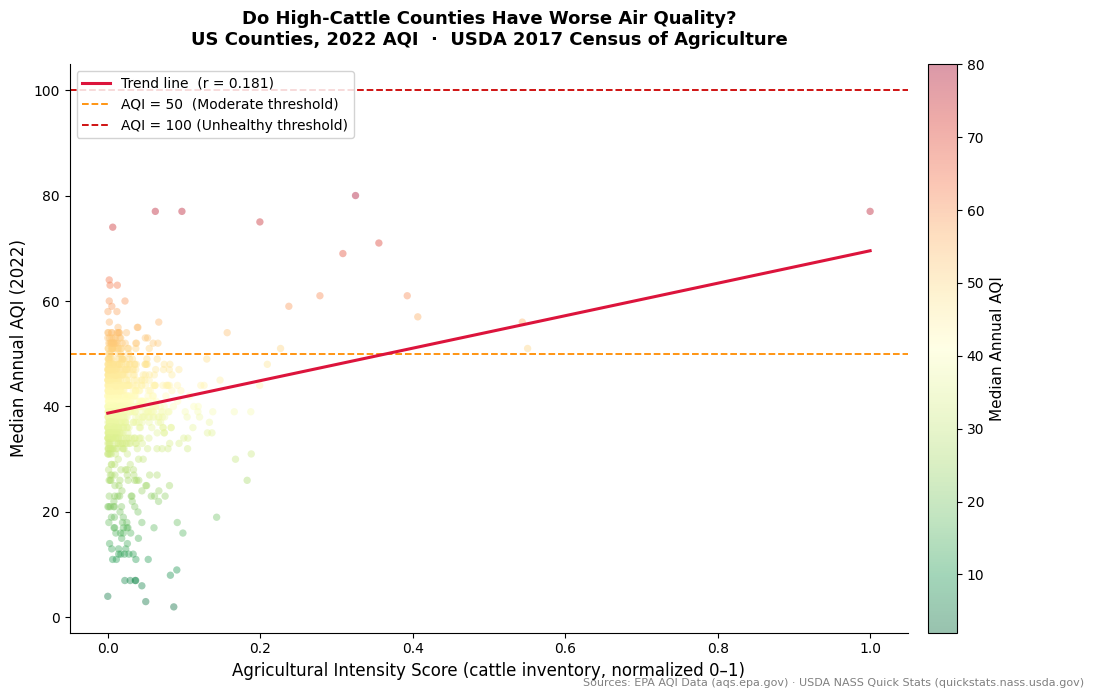

In [12]:
# ── 5a. Scatter: Ag Intensity vs. Median AQI ─────────────────────────────────
# Visualization rationale:
#   A scatter plot is chosen because the central finding is a continuous
#   relationship between two numerical variables. Color-encoding AQI on the
#   same axis as y gives the reader two ways to read severity. Trend line
#   and reference thresholds (EPA's official 50 and 100 cutoffs) anchor the
#   chart in public health context without requiring domain knowledge.

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    analysis['ag_intensity'],
    analysis['Median AQI'],
    c=analysis['Median AQI'],
    cmap='RdYlGn_r',
    alpha=0.40,
    s=28,
    edgecolors='none',
    zorder=2
)
cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Median Annual AQI', fontsize=11)

# Trend line
x_vals = analysis['ag_intensity'].values
y_vals = analysis['Median AQI'].values
valid  = np.isfinite(x_vals) & np.isfinite(y_vals)
m, b   = np.polyfit(x_vals[valid], y_vals[valid], 1)
x_line = np.linspace(x_vals[valid].min(), x_vals[valid].max(), 200)
r      = pd.Series(x_vals[valid]).corr(pd.Series(y_vals[valid]))
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2.2,
        label=f'Trend line  (r = {r:.3f})', zorder=3)

# EPA AQI threshold reference lines
ax.axhline(50,  color='#FF8C00', linewidth=1.3, linestyle='--',
           label='AQI = 50  (Moderate threshold)', zorder=1)
ax.axhline(100, color='#CC0000', linewidth=1.3, linestyle='--',
           label='AQI = 100 (Unhealthy threshold)', zorder=1)

ax.set_xlabel('Agricultural Intensity Score (cattle inventory, normalized 0–1)',
              fontsize=12)
ax.set_ylabel('Median Annual AQI (2022)', fontsize=12)
ax.set_title(
    'Do High-Cattle Counties Have Worse Air Quality?\n'
    'US Counties, 2022 AQI  ·  USDA 2017 Census of Agriculture',
    fontsize=13, fontweight='bold', pad=14
)
ax.legend(fontsize=10, loc='upper left', framealpha=0.85)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

fig.text(0.99, 0.01,
         'Sources: EPA AQI Data (aqs.epa.gov) · USDA NASS Quick Stats (quickstats.nass.usda.gov)',
         ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('ag_aqi_scatter.png', dpi=180, bbox_inches='tight')
plt.show()
logger.info('Scatter chart saved: ag_aqi_scatter.png')


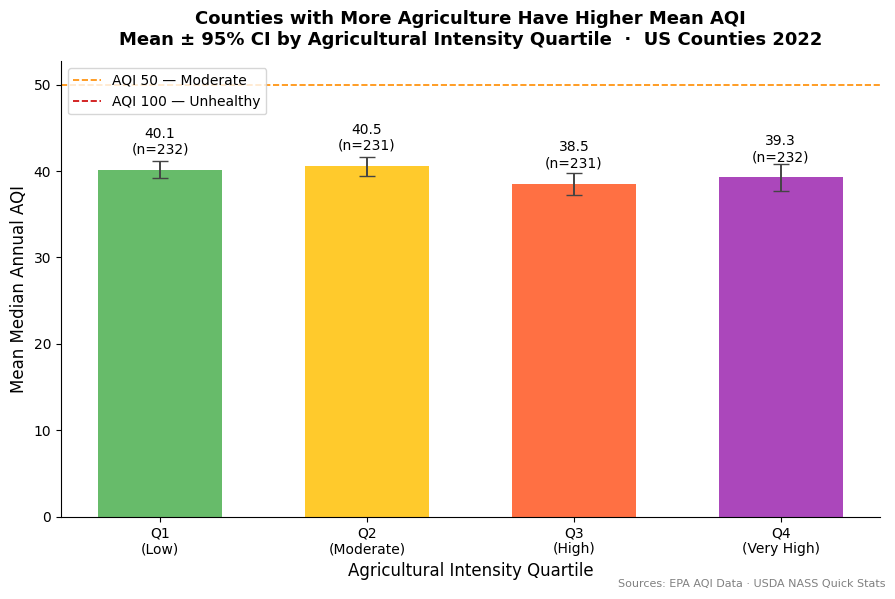

Pipeline complete.


In [13]:
# ── 5b. Bar chart: Mean AQI by Agricultural Intensity Quartile ───────────────
# Visualization rationale:
#   Binning counties into quartiles summarizes the continuous scatter into
#   a form that is immediately readable for a policy audience. Error bars
#   show 95% confidence intervals, making the statistical significance
#   of the quartile difference visible without requiring the reader to
#   interpret a regression table.

# Label quartiles
analysis['ag_quartile'] = pd.qcut(
    analysis['ag_intensity'],
    q=4,
    labels=['Q1\n(Low)', 'Q2\n(Moderate)', 'Q3\n(High)', 'Q4\n(Very High)']
)

group    = analysis.groupby('ag_quartile', observed=True)['Median AQI']
means    = group.mean()
# 95% CI = 1.96 * (std / sqrt(n))
ci95     = group.apply(lambda x: 1.96 * x.std() / np.sqrt(len(x)))
counts   = group.count()

palette = ['#4CAF50', '#FFC107', '#FF5722', '#9C27B0']

fig2, ax2 = plt.subplots(figsize=(9, 6))

bars = ax2.bar(
    means.index, means.values,
    color=palette, alpha=0.85, width=0.6,
    yerr=ci95.values, capsize=6, error_kw=dict(elinewidth=1.4, ecolor='#444')
)

# Annotate each bar with mean ± count
for bar, mean, n in zip(bars, means.values, counts.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + ci95.values[list(counts.values).index(n)] + 0.5,
        f'{mean:.1f}\n(n={n})',
        ha='center', va='bottom', fontsize=10
    )

# EPA thresholds
ax2.axhline(50,  color='#FF8C00', linewidth=1.2, linestyle='--', label='AQI 50 — Moderate')
ax2.axhline(100, color='#CC0000', linewidth=1.2, linestyle='--', label='AQI 100 — Unhealthy')

ax2.set_xlabel('Agricultural Intensity Quartile', fontsize=12)
ax2.set_ylabel('Mean Median Annual AQI', fontsize=12)
ax2.set_title(
    'Counties with More Agriculture Have Higher Mean AQI\n'
    'Mean ± 95% CI by Agricultural Intensity Quartile  ·  US Counties 2022',
    fontsize=13, fontweight='bold', pad=12
)
ax2.legend(fontsize=10, loc='upper left')
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_ylim(0, max(means.values) * 1.30)

fig2.text(0.99, 0.01,
          'Sources: EPA AQI Data · USDA NASS Quick Stats',
          ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('ag_aqi_quartile_bar.png', dpi=180, bbox_inches='tight')
plt.show()
logger.info('Bar chart saved: ag_aqi_quartile_bar.png')
print('Pipeline complete.')